# Image processing reprise

This is a reprise of basic concepts you should already be familiar with. 



Are you ready? Let's get it started!

In [3]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

## Digital images

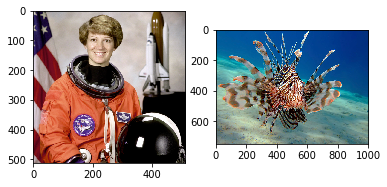

In [5]:
from skimage import data

astro = data.astronaut() # scikit-image comes already with some images (try to use the <TAB> key on data.)
fish = data.imread('lionfish.jpg') # or you can load a custom one

plt.subplot(1,2,1)
plt.imshow(astro)

plt.subplot(1,2,2)
plt.imshow(fish);

Can you guess data type and shape of the images?

In [6]:
print("image data type is: {}".format(type(astro)))
print("image shape is: {}".format(astro.shape))

image data type is: <class 'numpy.ndarray'>
image shape is: (512, 512, 3)


As expected, an *RGB* image is stored in memory as a three dimensional array ($shape = rows \times columns \times channels$). The intensities of each color channel are saved in a separate matrix.

Do you remember how to slice a <font face="TrueType">numpy.array</font>? Try to extract the three color channels from an image of choice and print their shape.

In [7]:
R = astro[:,:,0]
G = astro[:,:,1]
B = astro[:,:,2]
print("R shape is: {}".format(R.shape))
print("G shape is: {}".format(G.shape))
print("B shape is: {}".format(B.shape))

R shape is: (512, 512)
G shape is: (512, 512)
B shape is: (512, 512)


Let's try to inspect the content of a channel, for instance printing the first 5 elements of the first 3 lines of the red one.

In [8]:
print(R[:3,:5])

[[154 109  63  54  76]
 [177 144 113 106 128]
 [201 182 168 159 167]]


It looks like an image is stored in memory as a matrix filled with integer numbers. Can you guess the right range? Check it out in the next box.

Hint: you can use <font face="TrueType">np.max</font> and <font face="TrueType">np.min</font> on any input <font face="TrueType">numpy.array</font>.

In [9]:
print("Max value for the red channel: {}".format(np.max(R)))
print("Min value for the red channel: {}".format(np.min(R)))

Max value for the red channel: 255
Min value for the red channel: 0


8-bit images are stored in memory as matrices filled with integer numbers spanning between $0$ and $255$. However, sometimes it is useful to represent an image as a matrix of float spanning from $0$ to $1$. Write a Python function that implements such normalization and test it on an input matrix.

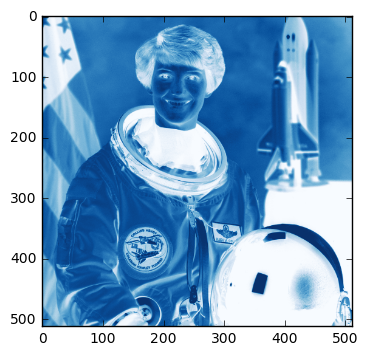

In [22]:
def my_uint2float(img):
    return (img - np.min(img)) / (np.max(img) - np.min(img))
plt.imshow(my_uint2float(R), cmap='Blues');

Well done. However, <font face="TrueType">skimage</font> can do that for us. Check the documentation of <a href="http://scikit-image.org/docs/dev/api/skimage.html#skimage.img_as_float"><font face="TrueType">skimage.img_as_float</font></a>.

In [12]:
import skimage
skimage.img_as_float??

Now, apply your new function on the three channels and try to visualize them in separate sections of the same figure. In which channel do you expect the astronaut suit will have highest values?

Hint 1: use <a href="http://matplotlib.org/api/colorbar_api.html"><font face="TrueType">plt.colorbar</font></a> to see the color mapping.

Hint 2: stick to the same colormap used before

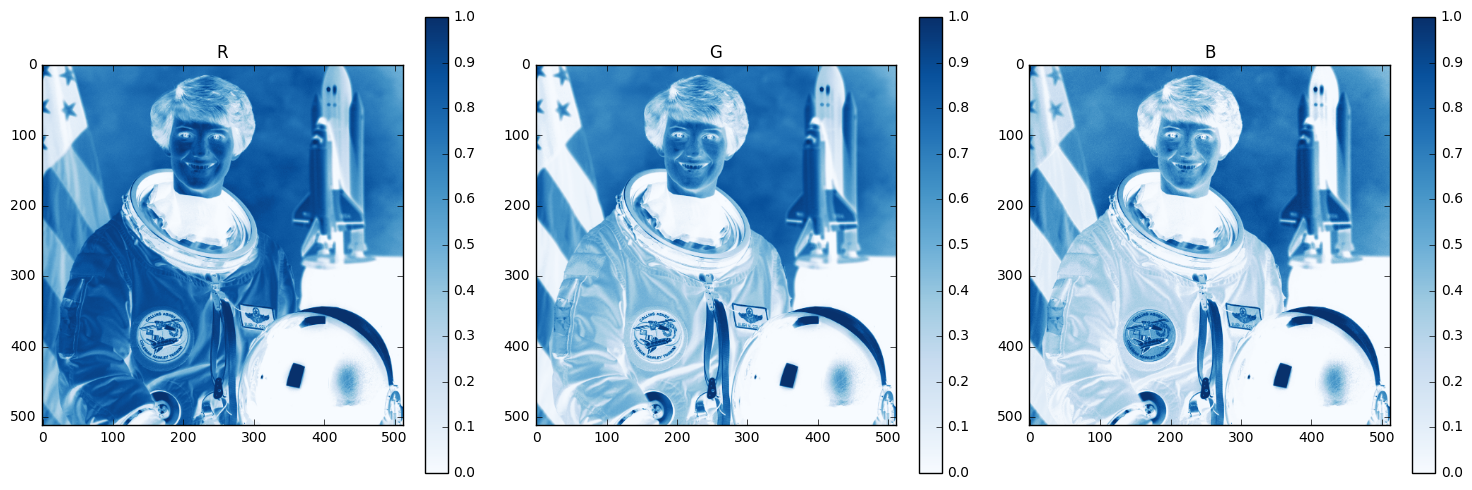

In [21]:
plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.imshow(my_uint2float(R), cmap='Blues');
plt.colorbar(orientation='vertical')
plt.title('R')

plt.subplot(1,3,2)
plt.imshow(my_uint2float(G), cmap='Blues');
plt.title('G')
plt.colorbar(orientation='vertical')

plt.subplot(1,3,3)
plt.imshow(my_uint2float(B), cmap='Blues');
plt.title('B')
plt.colorbar(orientation='vertical')

plt.tight_layout() # a handy command that increases spacing between subplots

Did you guess the right color channel? Bravo! Let's move on.

## RGB to grayscale conversion

So, a color image is a collection of three matrices each one representing a different color channel. How can we represent a grayscale image? How many *color channels* do we need? We know that it's possible to encode a color image in grayscale using the following linear transformation:

$Y = 0.2125 \cdot R + 0.7154 \cdot G + 0.0721 \cdot B$

*The coefficients represent the measured intensity perception of typical trichromat humans, depending on the primaries being used; in particular, human vision is most sensitive to green and least sensitive to blue.* [cit. <a href="https://en.wikipedia.org/wiki/Grayscale">Wikipedia</a>]

Write a Python function that converts the three channels of an input RGB image to float and then combines them in a grayscale encoding.

In [40]:
def my_rgb2gray(img):
    return 0.2125 * my_uint2float(img[:,:,0]) + 0.7154 * my_uint2float(img[:,:,1]) + 0.0721 * my_uint2float(img[:,:,2])

Now test it on one of the images above (to obtain more pleasant results try to specify the option <font face="TrueType">cmap='gray'</font> for the function <font face="TrueType">plt.imshow</font>).

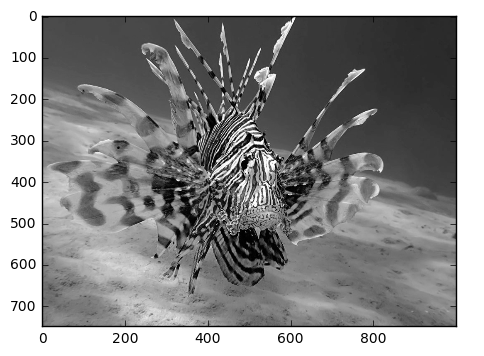

In [41]:
plt.imshow(my_rgb2gray(fish), cmap='gray');

Very good. We developed our grayscale conversion utility, but as you can imagine <font face="TrueType">skimage</font> can do that for us. Import the <font face="TrueType">color</font> module from the main library and check the help function for <a href="http://scikit-image.org/docs/dev/api/skimage.color.html#skimage.color.rgb2gray"><font face="TrueType">color.rgb2gray</font></a>.

In [42]:
from skimage import color
color.rgb2gray??

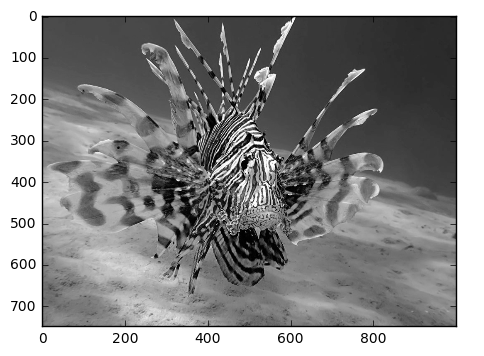

In [43]:
plt.imshow(color.rgb2gray(fish), cmap='gray');

Apparently the two functions return the same thing. But, how can we be sure of that? In other words, can we measure the similarity between two images (matrices)? 

The answer is: of course we can, and there are several ways to to that. Let's introduce here the most basic image distance measure.

The key idea here is to unroll the two images $A$ and $B$ with shape <font face="TrueType">(m, n)</font>, in two vectors $a$ and $b$ shaped as <font face="TrueType">(m $\cdot$ n, 1)</font>. Then a simple distance between them can be evaluated as follows.

$$\text{RSS} = \sum_{i=0}^{m\cdot n} (a_i - b_i)^2$$

This measure is known as <a href="https://en.wikipedia.org/wiki/Residual_sum_of_squares">Residual Sum of Squares</a> and it's gonna be useful in the next classes.

Implement a Python function that calculates the RSS between two input images and test it on the output obtained from <font face="TrueType">color.rgb2gray</font> and <font face="TrueType">my_rgb2gray</font> on the same image.

In [44]:
def RSS(a, b):
    return sum((a.ravel() - b.ravel())**2)

In [45]:
fish1 = color.rgb2gray(fish)
fish2= my_rgb2gray(fish)
print("RSS(fish1, fish2) = {}".format(RSS(fish1, fish2)))

RSS(fish1, fish2) = 0.0


Did you get $RSS=0$? Good.

## Histograms

Another strategy to check the distance between images is to take advantage of their color intensity distribution on the three channels, let's try to visualize them as histograms using the image of the lionfish.

Hint: check the documentation of  <font face="TrueType">plt.hist</font>.

In [46]:
plt.hist??

/anaconda3/lib/python3.6/site-packages/matplotlib/axes/_axes.py:6462: UserWarning: The 'normed' kwarg is deprecated, and has been replaced by the 'density' kwarg.
  warnings.warn("The 'normed' kwarg is deprecated, and has been "


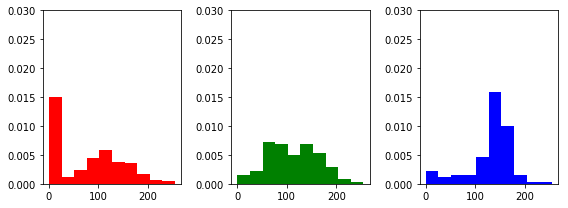

In [10]:
R = fish[:,:,0]
G = fish[:,:,1]
B = fish[:,:,2]

plt.figure(figsize=(8,3))

plt.subplot(1,3,1)
plt.hist(R.ravel(), normed=True, color='R');
plt.ylim([0,0.03])


plt.subplot(1,3,2)
plt.hist(G.ravel(), normed=True, color='G');
plt.ylim([0,0.03])

plt.subplot(1,3,3)
plt.ylim([0,0.03])
plt.hist(B.ravel(), normed=True, color='B');

plt.tight_layout() # a handy command that increases spacing between subplots

From those histograms it looks like the blue channel can be used to discriminate the foreground (a lionfish) from the background. This is gonna be the goal of the next section.

## Background suppression

A <i>binary mask</i> is an simple but effective way to perform a fast background suppression. You can obtain a binary mask in several ways, let's see an example. Create $A$: a simple $3\times 3$ matrix and then print a binary mask corresponding to the positions where its values are bigger than a certain threshold.

In [22]:
A = np.array([[2,2,2], [2,3,2], [2,4,2]])
print(A>2)

[[False False False]
 [False  True False]
 [False  True False]]


Easy, right? Now you can perform a simple background suppression identifying two thresholds from the histogram above and then representing the binary mask of the values lying in between them.

Hint: check the documentation for <font face="TrueType">np.multiply</font>.

In [ ]:
np.multiply??

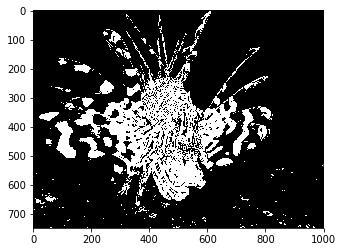

In [11]:
mask = ~np.multiply(B > 100, B < 200)
plt.imshow(mask, cmap='gray');

We may think of improving a bit our mask performing some morphological operations (**optional**).

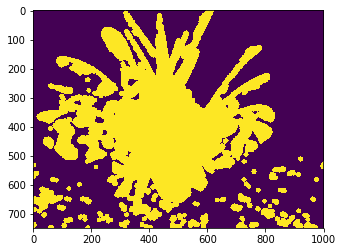

In [12]:
from skimage import morphology

selem = morphology.disk(8)
mask2 = morphology.dilation(mask, selem)

plt.imshow(mask2);

Now we can finally suppress the background in our image.

Hint 1: with <font face="TrueType">numpy</font> arrays you can use <font face="TrueType">bool</font> indexes.

Hint 2: to recompose an image that was previously decomposed in its three channels you can use <font face="TrueType">np.dstack</font>.

In [ ]:
np.dstack??

Hint 3: <font face="TrueType">numpy</font> has some utilities to initialize matrices and vectors, check for instance <font face="TrueType">np.ones</font> or <font face="TrueType">np.zeros</font>.

In [ ]:
np.ones??

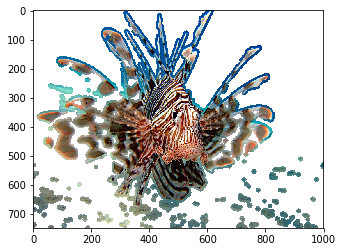

In [13]:
R2 = np.ones_like(R)*255
G2 = np.ones_like(G)*255
B2 = np.ones_like(B)*255

R2[mask2] = R[mask2]
G2[mask2] = G[mask2]
B2[mask2] = B[mask2]

fish2 = np.dstack((R2,G2,B2))
plt.imshow(fish2);